In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
df = pd.read_csv("/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/processed/dataset_final_canarias.csv")
df.head()

,id,owner,secret,server,farm,title,ispublic,isfriend,isfamily,datetaken,...,geo_is_family,media,media_status,upgrade_sizes,url_z,height_z,width_z,isla,owner_location,Tipo_behavior
0,51863841040,185509771@N03,c10e16cd99,65535,66,Sumiyoshi Maru No.10,1,0,0,2020-01-02 10:49:30,...,0,photo,ready,NaN,https://live.staticflickr.com/65535/5186384104...,427.0,640.0,Gran Canaria,Desconocida,Desconocido
1,51018224063,185509771@N03,e8f2abee90,65535,66,Fukuyoshi Maru No.68 (Spy Ship?),1,0,0,2020-01-02 10:55:45,...,0,photo,ready,NaN,https://live.staticflickr.com/65535/5101822406...,427.0,640.0,Gran Canaria,Desconocida,Desconocido
2,51871696249,185509771@N03,be53e04e09,65535,66,Koryo Maru No.15,1,0,0,2020-01-02 10:59:28,...,0,photo,ready,NaN,https://live.staticflickr.com/65535/5187169624...,427.0,640.0,Gran Canaria,Desconocida,Desconocido
3,49910279663,50866194@N03,723db6971a,65535,66,"Puerto Los Cristianos I, Isla de Tenerife, Spain",1,0,0,2020-01-02 11:26:21,...,0,photo,ready,"['h', 'k', '3k', '4k', '5k', '6k', 'o']",https://live.staticflickr.com/65535/4991027966...,427.0,640.0,Tenerife,Desconocida,Turista
4,50225960818,50866194@N03,c493c6f458,65535,66,"Puerto Los Cristianos II, Isla de Tenerife, Spain",1,0,0,2020-01-02 11:46:52,...,0,photo,ready,"['h', 'k', '3k', '4k', '5k', '6k', 'o']",https://live.staticflickr.com/65535/5022596081...,427.0,640.0,Tenerife,Desconocida,Turista


In [14]:
df.columns

Index(['id', 'owner', 'secret', 'server', 'farm', 'title', 'ispublic',
       'isfriend', 'isfamily', 'datetaken', 'datetakengranularity',
       'datetakenunknown', 'ownername', 'views', 'tags', 'latitude',
       'longitude', 'accuracy', 'context', 'place_id', 'woeid',
       'geo_is_public', 'geo_is_contact', 'geo_is_friend', 'geo_is_family',
       'media', 'media_status', 'upgrade_sizes', 'url_z', 'height_z',
       'width_z', 'isla', 'owner_location', 'Tipo_behavior'],
      dtype='str')

In [15]:
tabla_resumen = (
    df.groupby(["isla", "Tipo_behavior"])
      .size()
      .reset_index(name="count")
)

tabla_resumen

,isla,Tipo_behavior,count
0,El Hierro,Desconocido,306
1,El Hierro,Local,44
2,El Hierro,Turista,743
3,Fuerteventura,Desconocido,773
4,Fuerteventura,Local,1543
5,Fuerteventura,Turista,1755
6,Gran Canaria,Desconocido,1562
7,Gran Canaria,Local,2184
8,Gran Canaria,Turista,3190
9,La Gomera,Desconocido,808


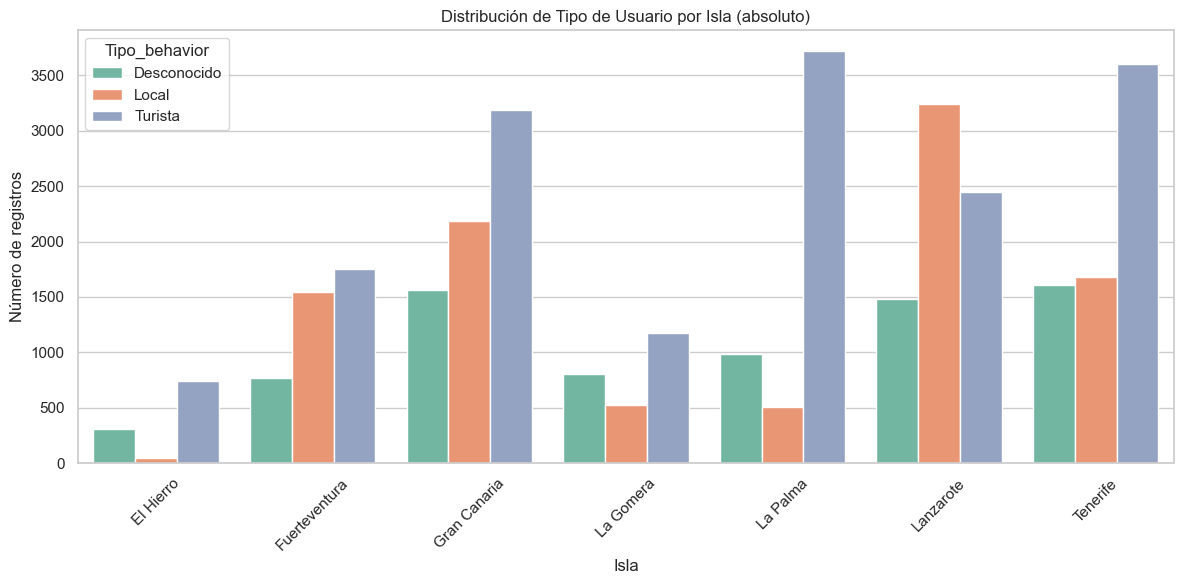

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_resumen,
    x="isla",
    y="count",
    hue="Tipo_behavior"
)

plt.title("Distribución de Tipo de Usuario por Isla (absoluto)")
plt.xlabel("Isla")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

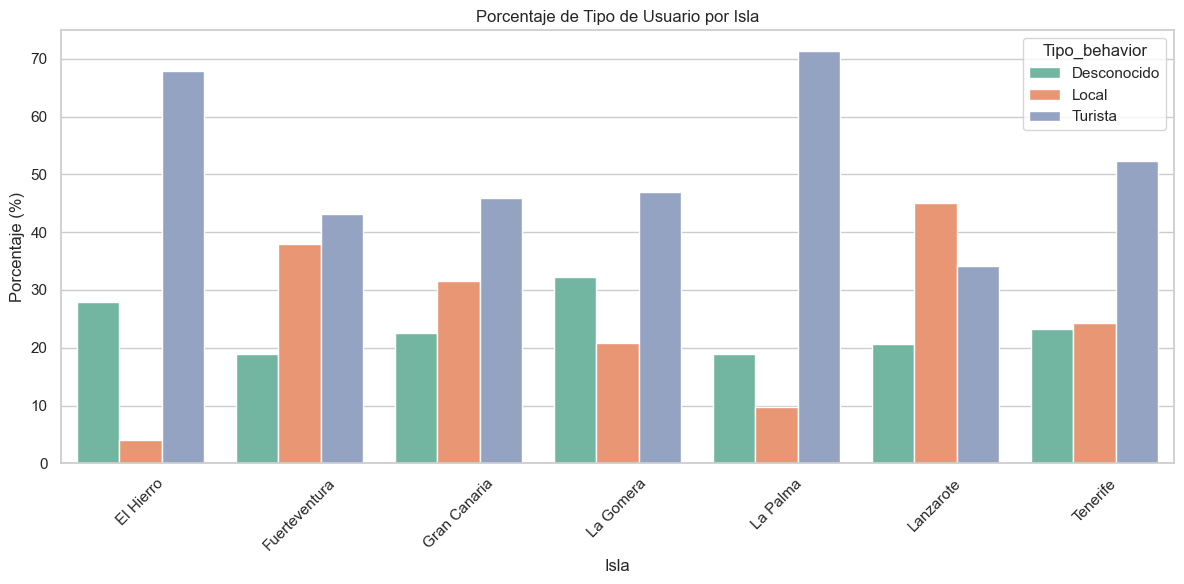

In [17]:
tabla_pct = tabla_resumen.copy()
tabla_pct["pct"] = tabla_pct["count"] / tabla_pct.groupby("isla")["count"].transform("sum") * 100

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_pct,
    x="isla",
    y="pct",
    hue="Tipo_behavior"
)

plt.title("Porcentaje de Tipo de Usuario por Isla")
plt.xlabel("Isla")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
dfB = pd.read_csv("/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/processed/dataset_final_canarias_2prueba.csv")
dfB.head()

,id,owner,secret,server,farm,title,ispublic,isfriend,isfamily,datetaken,...,geo_is_family,media,media_status,url_z,height_z,width_z,isla,upgrade_sizes,owner_location,Tipo_behavior
0,53447794530,147804036@N08,39566394f3,65535,66,A7402861,1,0,0,2024-01-01 10:01:13,...,0,photo,ready,https://live.staticflickr.com/65535/5344779453...,640.0,427.0,Lanzarote,NaN,Desconocida,Turista
1,53457905206,147804036@N08,e282636385,65535,66,A7402873,1,0,0,2024-01-01 10:11:48,...,0,photo,ready,https://live.staticflickr.com/65535/5345790520...,427.0,640.0,Lanzarote,NaN,Desconocida,Turista
2,53442850227,44614344@N07,8c8e1a7d36,65535,66,Iglesia de San Andrés Apóstol,1,0,0,2024-01-01 10:25:26,...,0,photo,ready,https://live.staticflickr.com/65535/5344285022...,449.0,640.0,Tenerife,NaN,Desconocida,Desconocido
3,53456979167,147804036@N08,be44883c56,65535,66,A7402884,1,0,0,2024-01-01 10:54:20,...,0,photo,ready,https://live.staticflickr.com/65535/5345697916...,427.0,640.0,Lanzarote,NaN,Desconocida,Turista
4,53458031573,147804036@N08,79dee0b891,65535,66,A7402905,1,0,0,2024-01-01 10:56:32,...,0,photo,ready,https://live.staticflickr.com/65535/5345803157...,427.0,640.0,Lanzarote,NaN,Desconocida,Turista


In [8]:
tabla_resumen = (
    dfB.groupby(["isla", "Tipo_behavior"])
      .size()
      .reset_index(name="count")
)

tabla_resumen

,isla,Tipo_behavior,count
0,El Hierro,Desconocido,41
1,El Hierro,Turista,683
2,Fuerteventura,Desconocido,326
3,Fuerteventura,Local,1950
4,Fuerteventura,Turista,1499
5,Gran Canaria,Desconocido,1208
6,Gran Canaria,Local,3288
7,Gran Canaria,Turista,2792
8,La Gomera,Desconocido,194
9,La Gomera,Local,43


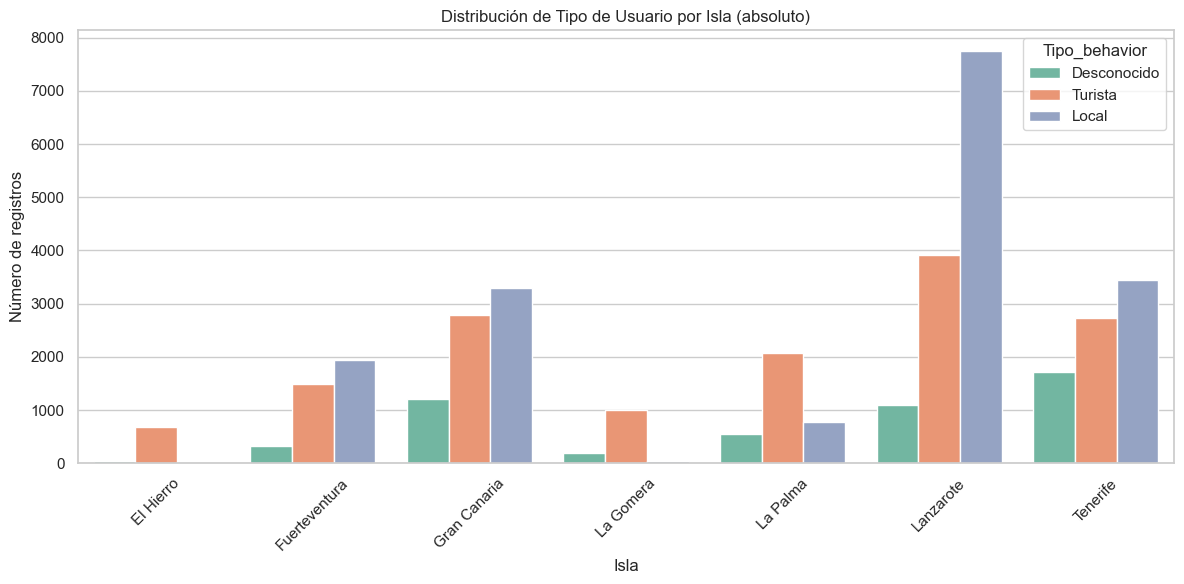

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_resumen,
    x="isla",
    y="count",
    hue="Tipo_behavior"
)

plt.title("Distribución de Tipo de Usuario por Isla (absoluto)")
plt.xlabel("Isla")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

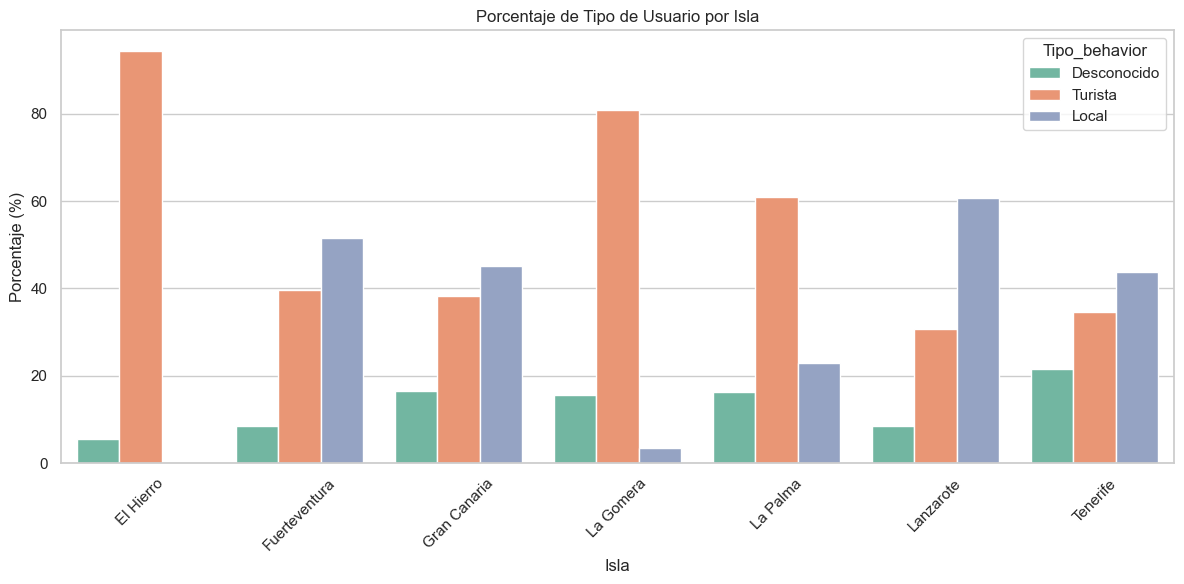

In [10]:
tabla_pct = tabla_resumen.copy()
tabla_pct["pct"] = tabla_pct["count"] / tabla_pct.groupby("isla")["count"].transform("sum") * 100

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_pct,
    x="isla",
    y="pct",
    hue="Tipo_behavior"
)

plt.title("Porcentaje de Tipo de Usuario por Isla")
plt.xlabel("Isla")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
from scipy.stats import chi2_contingency

def sample_by_isla(df, n=300, random_state=None):

    out = []
    for isla, sub in df.groupby("isla"):
        out.append(sub.sample(n=min(n, len(sub)), random_state=random_state))
    return pd.concat(out, ignore_index=True)


def chi_por_isla(df1, df2):
    categorias = sorted(list(
        set(df1["Tipo_behavior"]).union(set(df2["Tipo_behavior"]))
    ))

    resultados = []

    for isla in sorted(df1["isla"].unique()):
        sub1 = df1[df1["isla"] == isla]["Tipo_behavior"].value_counts()
        sub2 = df2[df2["isla"] == isla]["Tipo_behavior"].value_counts()

        contingencia = pd.DataFrame({
            "Muestra1": [sub1.get(cat, 0) for cat in categorias],
            "Muestra2": [sub2.get(cat, 0) for cat in categorias]
        }, index=categorias)

        chi2, p, dof, expected = chi2_contingency(contingencia)

        conclusion = "Estable (p>0.05)" if p > 0.05 else "Inestable (p<0.05)"

        resultados.append({
            "Isla": isla,
            "Chi2": chi2,
            "p-value": p,
            "Conclusión": conclusion
        })

    return pd.DataFrame(resultados)

In [28]:
import pandas as pd

def visualizar_muestras(m1, m2):
    m1_plot = m1.copy()
    m2_plot = m2.copy()

    m1_plot["Muestra"] = "Muestra 1"
    m2_plot["Muestra"] = "Muestra 2"

    df_plot = pd.concat([m1_plot, m2_plot], ignore_index=True)

    tabla = (
        df_plot.groupby(["isla", "Tipo_behavior", "Muestra"])
               .size()
               .reset_index(name="count")
    )

    plt.figure(figsize=(16, 8))
    sns.barplot(
        data=tabla,
        x="isla",
        y="count",
        hue="Muestra",
        palette="Set2",
        ci=None
    )
    plt.title("Comparación entre Muestra 1 y Muestra 2 (totales por isla)")
    plt.xlabel("Isla")
    plt.ylabel("Número de registros")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [29]:
m1 = sample_by_isla(df, n=300, random_state=0)
m2 = sample_by_isla(df, n=300, random_state=42)

resultado = chi_por_isla(m1, m2)
print(resultado)

            Isla      Chi2   p-value        Conclusión
0      El Hierro  1.629535  0.442742  Estable (p>0.05)
1  Fuerteventura  5.017181  0.081383  Estable (p>0.05)
2   Gran Canaria  2.323631  0.312918  Estable (p>0.05)
3      La Gomera  0.604935  0.738992  Estable (p>0.05)
4       La Palma  0.403898  0.817137  Estable (p>0.05)
5      Lanzarote  3.378680  0.184641  Estable (p>0.05)
6       Tenerife  0.633008  0.728692  Estable (p>0.05)


**Evaluación de la estabilidad interna del clasificador mediante pruebas de Chi‑cuadrado**


Con el objetivo de evaluar la robustez del clasificador frente a variaciones en el muestreo, se realizaron pruebas de estabilidad interna tomando dos muestras aleatorias independientes de 300 fotografías por isla dentro del mismo dataset.

Para cada isla se construyó una tabla de contingencia con las frecuencias relativas de las tres categorías de usuario (Local, Turista y Desconocido) en ambas muestras. Posteriormente, se aplicó un test Chi‑cuadrado de independencia para contrastar la hipótesis:

_H₀_: La distribución de tipos de usuario es la misma en ambas muestras (clasificador estable).

_H₁_: Las distribuciones difieren significativamente (clasificador inestable).

En todas las islas el valor p fue superior al umbral de significancia α = 0.05, por lo que no se detectaron diferencias significativas entre las dos muestras independientes. Esto indica que el clasificador produce resultados consistentes incluso cuando se seleccionan subconjuntos diferentes del mismo dataset.


Por tanto, se concluye que el clasificador presenta una alta estabilidad interna, lo que refuerza su validez metodológica y su fiabilidad para el análisis del comportamiento turístico

**VISUALIZACIÓN CON EL DATASET FINAL "DATOS_CANARIAS.CSV"**

In [2]:
datos = pd.read_csv("/Users/cgsos/Documents/Cuarto/TFG/FLICKR/datos/processed/fotos_canarias.csv")
datos.head()

,id,owner,secret,server,farm,title,ispublic,isfriend,isfamily,datetaken,...,geo_is_family,media,media_status,url_z,height_z,width_z,isla,upgrade_sizes,owner_location,Tipo_behavior
0,51622309240,142285840@N08,5128e493c3,65535,66,Garachico,1,0,0,2021-01-01 08:31:20,...,0,photo,ready,https://live.staticflickr.com/65535/5162230924...,427.0,640.0,Tenerife,"['h', 'k', 'o']",Desconocida,Turista
1,50843298271,13156397@N00,d0974e3906,65535,66,Predator Rony...,1,0,0,2021-01-01 14:25:28,...,0,photo,ready,https://live.staticflickr.com/65535/5084329827...,640.0,457.0,Tenerife,NaN,Desconocida,Turista
2,51844319731,54012326@N06,4a2b8a178a,65535,66,Ripples de corriente romboides y placer litora...,1,0,0,2021-01-02 00:00:00,...,0,photo,ready,https://live.staticflickr.com/65535/5184431973...,640.0,526.0,Lanzarote,NaN,Desconocida,Turista
3,51826503189,54012326@N06,99aa5133ab,0,0,Estafilitos excéntricos (helictitas de lava) e...,1,0,0,2021-01-02 00:00:00,...,0,video,ready,https://live.staticflickr.com/31337/5182650318...,360.0,640.0,Lanzarote,NaN,Desconocida,Turista
4,50790617046,131806380@N05,05da99bf43,65535,66,EC-HBU ATR72 Binter Arrecife 02-04-02,1,0,0,2021-01-02 02:35:09,...,0,photo,ready,https://live.staticflickr.com/65535/5079061704...,427.0,640.0,Lanzarote,NaN,Desconocida,Desconocido


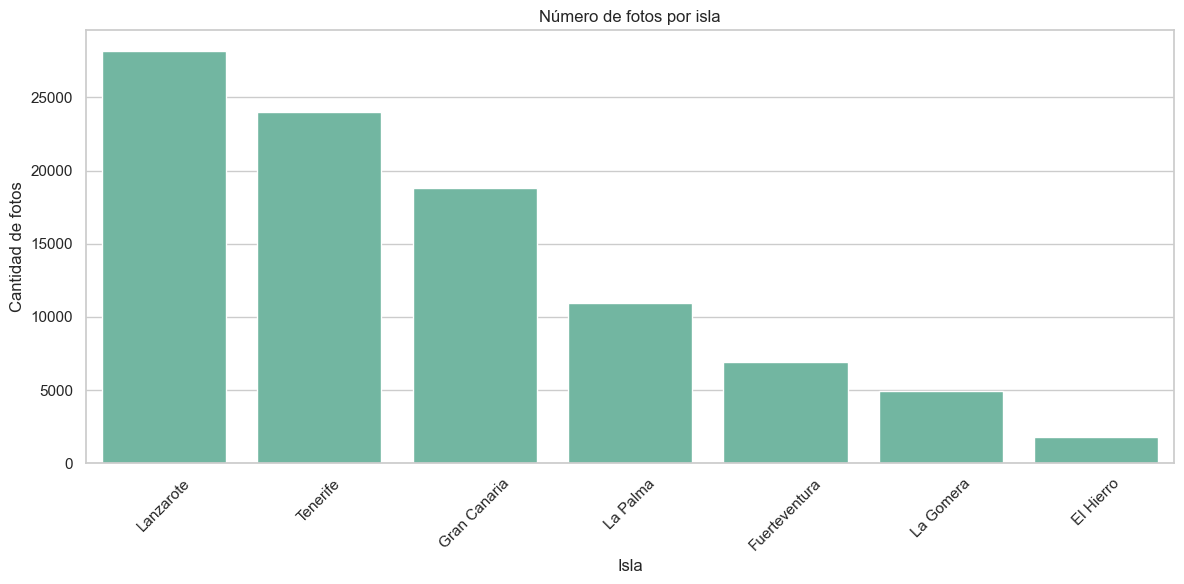

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.countplot(data=datos, x="isla", order=datos["isla"].value_counts().index)

plt.title("Número de fotos por isla")
plt.xlabel("Isla")
plt.ylabel("Cantidad de fotos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
datos['datetaken'] = pd.to_datetime(datos['datetaken'], errors='coerce')
datos['year'] = datos['datetaken'].dt.year
fotos_por_ano = (
    datos
    .groupby('year')
    .size()
    .reset_index(name='num_fotos')
    .sort_values('year')
)

print(fotos_por_ano)

   year  num_fotos
0  2021      18466
1  2022      17606
2  2023      21432
3  2024      18403
4  2025      16004
5  2026       3670


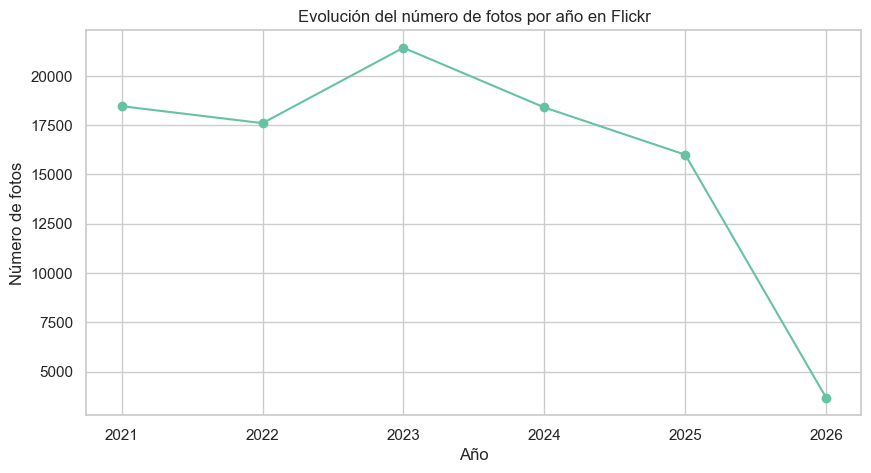

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(fotos_por_ano['year'], fotos_por_ano['num_fotos'], marker='o')

plt.xlabel('Año')
plt.ylabel('Número de fotos')
plt.title('Evolución del número de fotos por año en Flickr')
plt.grid(True)

plt.show()

In [7]:
tabla_resumen = (
    datos.groupby(["isla", "Tipo_behavior"])
      .size()
      .reset_index(name="count")
)

tabla_resumen

,isla,Tipo_behavior,count
0,El Hierro,Desconocido,73
1,El Hierro,Local,44
2,El Hierro,Turista,1702
3,Fuerteventura,Desconocido,873
4,Fuerteventura,Local,2903
5,Fuerteventura,Turista,3131
6,Gran Canaria,Desconocido,3431
7,Gran Canaria,Local,4991
8,Gran Canaria,Turista,10391
9,La Gomera,Desconocido,567


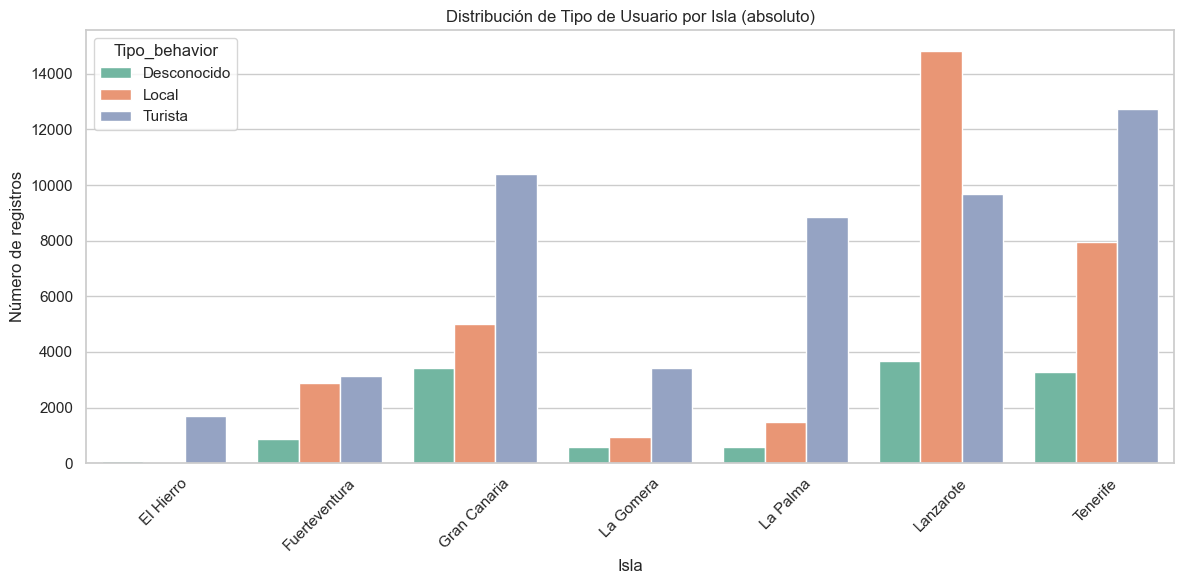

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_resumen,
    x="isla",
    y="count",
    hue="Tipo_behavior"
)

plt.title("Distribución de Tipo de Usuario por Isla (absoluto)")
plt.xlabel("Isla")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()